# W1D5 extra — K-Means and the shape it assumes — Lab

**Week 1 · Day 5 · Foundations** · Extra lab · optional

Today's main lab ran K-Means on twelve columns of customer data, where nobody can see what the
algorithm is doing. This one runs it on two columns, where you can see everything — and where it gets
the answer **wrong**.

The data is the same pair of half-moons you separated with a support vector machine on Thursday. That
model was told the answer and drew a curve. K-Means is told nothing, and the shape it can draw is
fixed before it sees a single point. Watching it fail is the fastest way to learn what it assumes.

**Time budget:** ~55 minutes. This lab is optional extra practice for Day 5.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٥ إضافي — خوارزمية K-Means والشكل الذي تفترضه

**الأسبوع ١ · اليوم ٥ · الأساسيات** · معمل إضافي · اختياري

معمل اليوم الأساسي شغّل K-Means على اثني عشر عمودًا من بيانات العملاء، حيث لا يستطيع أحد أن يرى ما
تفعله الخوارزمية. أما هذا المعمل فيشغّلها على عمودين، حيث ترى كل شيء — وحيث تُخطئ الجواب.

والبيانات هي زوج الهلالين نفسه الذي فصلته بآلة المتّجهات الداعمة يوم الخميس. ذلك النموذج أُخبِر
بالجواب فرسم منحنى. أما K-Means فلا يُخبَرها أحد بشيء، والشكل الذي تستطيع رسمه مُحدَّد قبل أن ترى نقطة
واحدة. ومشاهدتها وهي تفشل أسرع طريق لتعلّم ما تفترضه.

**الزمن المتوقّع:** نحو ٥٥ دقيقة. هذا المعمل إضافي اختياري لليوم الخامس.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Run K-Means on data you can see, and judge its answer against the truth with one number.
- Describe the two-step loop — assign, then move — by watching the centroids walk across the plot.
- State the assumption K-Means makes about cluster shape, and draw the boundary it is stuck with.
- Say why the elbow plot cannot warn you that clustering was the wrong tool.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- أن تُشغّل K-Means على بيانات تراها بعينك، وأن تحكم على جوابها مقابل الحقيقة برقم واحد.
- أن تصف الحلقة ذات الخطوتين — إسناد ثم تحريك — بمشاهدة المراكز وهي تمشي عبر الرسم.
- أن تذكر الافتراض الذي تفترضه K-Means عن شكل العناقيد، وأن ترسم الحدّ العالق عنده.
- أن تقول لماذا لا يستطيع رسم «الكوع» أن ينبّهك إلى أن التجميع كان الأداة الخطأ.

</div>

## About the data

**Dataset:** `moons_toy` — two interleaving half-moons · CC0, generated with seed 42 · 500 rows

Two columns, `x1` and `x2`, and a label that is 0 or 1 — 250 of each. The label exists, and you will
use it exactly once: to mark the answers after the algorithm has committed to its own. K-Means never
sees it.

**Watch out:** having a label here is a luxury of a teaching dataset. On the customer data in the main
lab there is nothing to check against, which is why that lab spends its time on the elbow and the
silhouette instead. Everything this lab shows you is still true there — you just cannot see it.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `moons_toy` — هلالان متداخلان · رخصة CC0 بالبذرة ٤٢ · ٥٠٠ صفّ

عمودان، `x1` و`x2`، وتسمية قيمتها صفر أو واحد — ٢٥٠ لكل فئة. والتسمية موجودة، وستستخدمها مرة واحدة
فقط: لتعليم الإجابات بعد أن تكون الخوارزمية قد التزمت بإجابتها. أما K-Means فلا تراها أبدًا.

**انتبه:** وجود تسمية هنا ترف من ترف بيانات التعليم. ففي بيانات العملاء في المعمل الأساسي لا يوجد ما
تقارن به، ولهذا يقضي ذلك المعمل وقته في الكوع ومعامل الظلّ بدلًا من ذلك. وكل ما يعرضه هذا المعمل
صحيح هناك أيضًا — غير أنك لا تستطيع رؤيته.

</div>

## Setup

Run the cell below first. It loads the moons, keeps the true labels aside in `y_true`, and defines
`plot_clusters(ax, X, labels, title, centres=None)` — it scatters the points coloured by whatever
grouping you hand it and marks the centroids with a black cross. Every plot in this lab uses it.

<div dir="rtl" align="right">

## التهيئة

شغّل الخلية أدناه أولًا. تُحمّل الهلالين، وتُبقي التسميات الحقيقية جانبًا في `y_true`، وتُعرّف
`plot_clusters(ax, X, labels, title, centres=None)` التي تنثر النقاط ملوّنة بحسب أي تجميع تمرّره
إليها وتُعلّم المراكز بعلامة سوداء. وكل رسم في هذا المعمل يستخدمها.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("moons_toy")
_df = pd.read_parquet(DATA)

FEATURES = ["x1", "x2"]
X = _df[FEATURES].to_numpy(dtype=float)
y_true = _df["label"].to_numpy(dtype=int)     # the answer. K-Means never sees it.


def plot_clusters(ax, X, labels, title, centres=None):
    """Scatter points coloured by `labels`, with the centroids marked. Written for you."""
    for value in np.unique(labels):
        mask = labels == value
        ax.scatter(X[mask, 0], X[mask, 1], s=14, label=f"group {value}")
    if centres is not None:
        ax.scatter(centres[:, 0], centres[:, 1], s=250, marker="X", color="black",
                   zorder=5, label="centroids")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


print(describe_dataset("moons_toy"))
print(f"\n{X.shape[0]} points x {X.shape[1]} columns | "
      f"true groups {np.bincount(y_true).tolist()}")
print("\n", versions())

📁 moons_toy: using cached file at C:\Users\ACER\AIEP_Olo_student\shared\data_cache\moons_toy.parquet
moons_toy  (500 rows, 0.01 MB)
  Source:  Built for this course
  Licence: CC0 (generated with sklearn.datasets.make_moons, seed 42)
  Target:  label

  EN: Two interleaving half-moons — not linearly separable, small enough to train a from-scratch NumPy network on in seconds, and 2-D so the decision boundary can be drawn. Used across W3D2-D5 so students compare like with like all week.
  AR: هلالان متداخلان — غير قابلين للفصل خطيًا، وصغيران بما يكفي لتدريب شبكة مكتوبة من الصفر بـ NumPy في ثوانٍ، وثنائيا البعد فيمكن رسم حدّ القرار. يُستخدمان من اليوم الثاني إلى الخامس في الأسبوع الثالث ليقارن الطلاب المتشابه بالمتشابه طوال الأسبوع.

  ⚠️  Watch out: Noise is set to 0.2, so perfect accuracy is impossible — a student chasing 100% is overfitting.
  ⚠️  انتبه: الضوضاء مضبوطة على ٠٫٢، فالدقة الكاملة مستحيلة؛ ومن يطارد ١٠٠٪ فهو يقع في فرط المطابقة.

500 points x 2 columns | true groups [250, 2

## Section 1 — Warm-up: let it cluster, then mark the answers  (≈15 min)

K-Means needs one thing from you: `k`, the number of groups. Here the honest answer is 2 — there are
two moons — so the algorithm is being given every advantage. It still gets it wrong, and that is worth
seeing before any theory.

<div dir="rtl" align="right">

## القسم الأول — الإحماء: دعها تُجمّع ثم علّم الإجابات (نحو ١٥ دقيقة)

تحتاج K-Means منك شيئًا واحدًا: `k`، أي عدد المجموعات. والجواب الصادق هنا هو ٢ — فهناك هلالان — أي أن
الخوارزمية تُعطى كل أفضلية ممكنة. ومع ذلك تُخطئ، وهذا يستحقّ المشاهدة قبل أي نظرية.

</div>

### Task 1.1 — cluster into two, then compare with the truth

Fit `KMeans(n_clusters=2, n_init=10, random_state=42)` on `X` and call it `kmeans`. Draw two panels
side by side: the clusters it found on the left, the true moons on the right.

Then score it. Cluster numbers are arbitrary — the algorithm's group 0 might be the true group 1 — so
use `adjusted_rand_score(y_true, kmeans.labels_)`, which compares *which points were grouped together*
and ignores the naming. It reads 1.0 for a perfect match and about 0.0 for random grouping.

<div dir="rtl" align="right">

### المهمة ١٫١ — جمّع إلى مجموعتين ثم قارن بالحقيقة

درّب `KMeans(n_clusters=2, n_init=10, random_state=42)` على `X` وسمِّه `kmeans`. وارسم لوحتين
متجاورتين: العناقيد التي وجدها على اليسار، والهلالان الحقيقيان على اليمين.

ثم قيّمه. فأرقام العناقيد اعتباطية — قد تكون مجموعة الخوارزمية صفر هي المجموعة الحقيقية واحد — لذا
استخدم `adjusted_rand_score(y_true, kmeans.labels_)` التي تقارن **أي النقاط جُمعت معًا** وتتجاهل
التسمية. وتساوي ١٫٠ عند التطابق التامّ ونحو ٠٫٠ عند التجميع العشوائي.

</div>

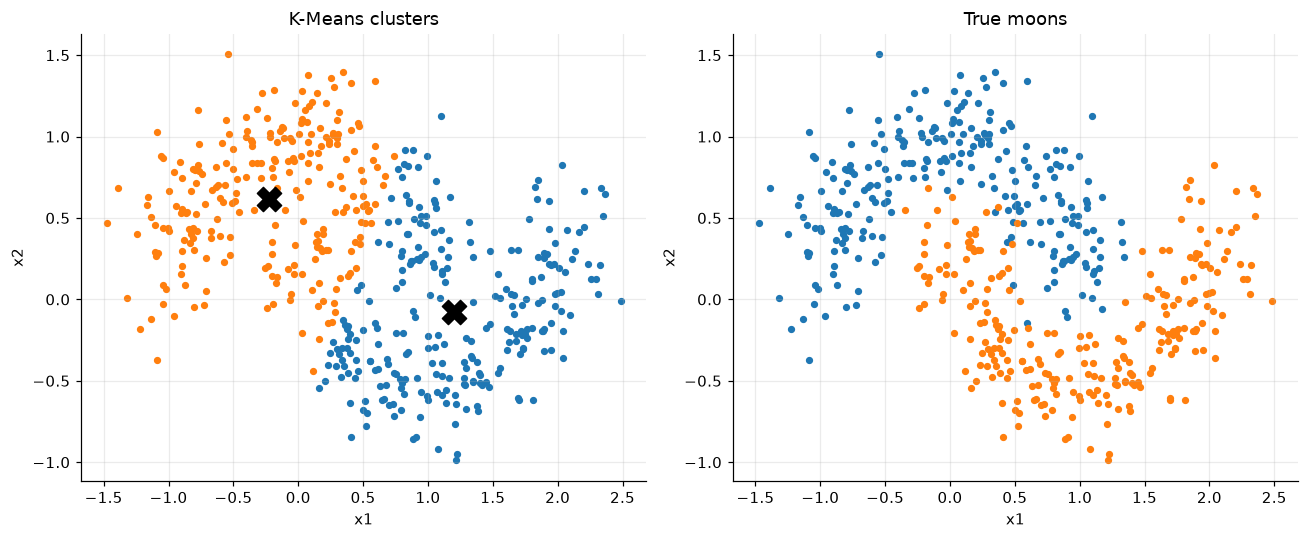

adjusted Rand index vs the truth : 0.2773
iterations to settle             : 9


In [3]:
# ────────────────────────────────────────────────────────────────────
# 1) KMeans is imported for you. n_init=10 means "try 10 starts and keep the best" —
#    leave it in, or your result changes every run.
# 2) After fitting, the answers are in kmeans.labels_ and the centres in
#    kmeans.cluster_centers_.
# 3) plt.subplots(1, 2, figsize=(12, 5)) gives you `axes`; call plot_clusters on each,
#    passing centres= only on the left one.
# 4) Store the score as `ari_moons`. The sanity check reads it.
# Search: "sklearn KMeans labels_ cluster_centers_ adjusted_rand_score"
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
#
# ١) الصنف KMeans مستورد لك. والوسيط n_init=10 يعني «جرّب عشر بدايات واحتفظ بأفضلها» —
#    أبقِه، وإلا تغيّرت نتيجتك في كل تشغيل.
# ٢) بعد التدريب تجد الإجابات في kmeans.labels_ والمراكز في
#    kmeans.cluster_centers_.
# ٣) السطر plt.subplots(1, 2, figsize=(12, 5)) يعطيك `axes`؛ استدعِ plot_clusters لكلٍّ منهما،
#    ومرّر centres= في اليسرى فقط.
# ٤) خزّن النتيجة باسم `ari_moons`. فالفحص يقرؤها.
# ابحث عن: "sklearn KMeans labels_ cluster_centers_ adjusted_rand_score"
# ────────────────────────────────────────────────────────────────────

# 1) درّب KMeans بـ k=2
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X)

# 2) ارسم لوحتين جنب بعض
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters(axes[0], X, kmeans.labels_, "K-Means clusters", centres=kmeans.cluster_centers_)
plot_clusters(axes[1], X, y_true, "True moons")
plt.tight_layout()
plt.show()

# 3) قيّم النتيجة
ari_moons = adjusted_rand_score(y_true, kmeans.labels_)

# TODO: Fit KMeans with k=2, plot its clusters beside the true moons, and score it with adjusted_rand_score into `ari_moons`.
# مهمة: درّب KMeans بـk=2، وارسم عناقيدها بجوار الهلالين الحقيقيين، وقيّمها بـ adjusted_rand_score في `ari_moons`.
print(f"adjusted Rand index vs the truth : {ari_moons:.4f}")
print(f"iterations to settle             : {kmeans.n_iter_}")

0.28. A perfect grouping would be 1.0 and a coin toss would be near 0.0, so this is a bad answer
dressed as a confident one — and if you look at the left panel you can see exactly how it went wrong.
It cut both moons in half, left and right, instead of separating one moon from the other.

That is not a bug, and running it again will not help. Look at where the two black crosses sit: one to
the left, one to the right. Every point simply joined whichever cross was nearer.

<div dir="rtl" align="right">

٠٫٢٨. التطابق التامّ يساوي ١٫٠ ورمية العملة تقارب ٠٫٠، فهذا جواب سيّئ في ثوب واثق — وإن نظرت إلى
اللوحة اليسرى رأيت كيف أخطأ بالضبط. فقد شطر كلا الهلالين نصفين، يمينًا ويسارًا، بدل أن يفصل هلالًا عن
هلال.

وليس هذا خللًا، ولن تنفع إعادة التشغيل. انظر إلى موضع العلامتين السوداوين: واحدة إلى اليسار وأخرى إلى
اليمين. فكل نقطة انضمّت ببساطة إلى العلامة الأقرب إليها.

</div>

## Section 2 — Core: the loop, the boundary, and the shape it wants  (≈30 min)

Three tasks, and they answer one question between them: *why* was that the answer, and what kind of
data would it have got right?

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: الحلقة والحدّ والشكل الذي تريده (نحو ٣٠ دقيقة)

ثلاث مهام، تُجيب مجتمعةً عن سؤال واحد: **لماذا** كان ذلك هو الجواب، وأيّ نوع من البيانات كانت ستُصيبه؟

</div>

### Task 2.1 — watch the centroids walk

K-Means repeats two steps until nothing moves: **assign** every point to its nearest centroid, then
**move** every centroid to the mean of the points that joined it.

`max_iter` caps how many times that pair runs. Fit one model per value in `SNAPSHOTS` with
`n_init=1, random_state=0` — one start, no best-of — and draw the four results in a row. The last one
is where the loop stops on its own.

<div dir="rtl" align="right">

### المهمة ٢٫١ — راقب المراكز وهي تمشي

تكرّر K-Means خطوتين حتى لا يتحرّك شيء: **إسناد** كل نقطة إلى أقرب مركز إليها، ثم **تحريك** كل مركز
إلى متوسّط النقاط التي انضمّت إليه.

والوسيط `max_iter` يحدّ عدد مرات تشغيل هذا الزوج. درّب نموذجًا لكل قيمة في `SNAPSHOTS` بـ
`n_init=1, random_state=0` — بداية واحدة بلا اختيار أفضل — وارسم النتائج الأربع في صفّ. والأخيرة هي
حيث تتوقّف الحلقة من تلقاء نفسها.

</div>

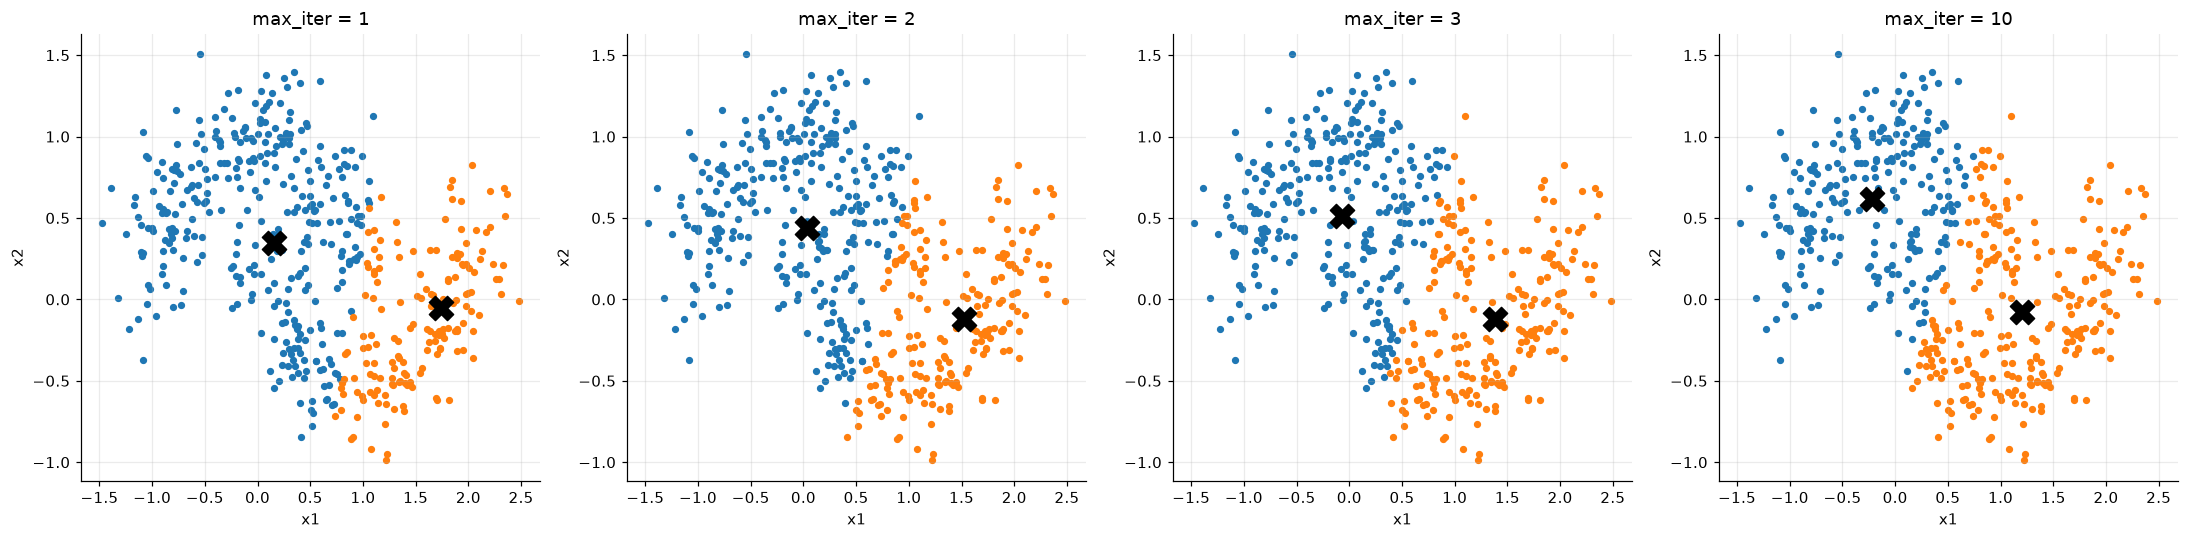

max_iter  1 -> ran 1 | centres [[0.154, 0.347], [1.737, -0.05]]
max_iter  2 -> ran 2 | centres [[0.03, 0.438], [1.527, -0.122]]
max_iter  3 -> ran 3 | centres [[-0.068, 0.51], [1.383, -0.12]]
max_iter 10 -> ran 9 | centres [[-0.222, 0.617], [1.201, -0.078]]


In [4]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over SNAPSHOTS zipped with the four axes, as you did for the C sweep on Thursday.
# 2) Inside: KMeans(n_clusters=2, n_init=1, max_iter=value, random_state=0).fit(X).
# 3) Plot each with plot_clusters, passing centres=, and title it with the iteration count.
# 4) Collect the fitted models into `steps` so the sanity check can count them.
# Search: "sklearn KMeans max_iter n_init single initialisation"
#
# ١) كرّر على SNAPSHOTS مقرونة بالمحاور الأربعة بـzip، كما فعلت في مسح C يوم الخميس.
# ٢) وداخلها: KMeans(n_clusters=2, n_init=1, max_iter=value, random_state=0).fit(X).
# ٣) ارسم كلًّا منها بـplot_clusters مع تمرير centres=، وعنونها بعدد التكرارات.
# ٤) اجمع النماذج المُدرَّبة في `steps` ليتمكّن الفحص من عدّها.
# ابحث عن: "sklearn KMeans max_iter n_init single initialisation"
# ────────────────────────────────────────────────────────────────────

SNAPSHOTS = [1, 2, 3, 10]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
steps = []
for value, ax in zip(SNAPSHOTS, axes):
    model = KMeans(n_clusters=2, n_init=1, max_iter=value, random_state=0)
    model.fit(X)
    plot_clusters(ax, X, model.labels_, f"max_iter = {value}", centres=model.cluster_centers_)
    steps.append(model)
plt.tight_layout()
plt.show()


# TODO: Fit one K-Means per value in SNAPSHOTS with a single start, draw the four panels in a row, and collect the models into `steps`.
# مهمة: درّب K-Means لكل قيمة في SNAPSHOTS ببداية واحدة، وارسم اللوحات الأربع في صفّ، واجمع النماذج في `steps`.
for value, model in zip(SNAPSHOTS, steps):
    centres = np.round(model.cluster_centers_, 3).tolist()
    print(f"max_iter {value:>2} -> ran {model.n_iter_} | centres {centres}")

The crosses drift apart a little on each pass and then stop. Nine iterations is all it takes, and the
last two panels are nearly identical — that is convergence, and it means only that the loop reached a
fixed point. Not that the fixed point is any good.

Worth noticing: the shape of the answer was already decided after iteration one. The crosses moved by
fractions after that. A run that converges quickly and confidently to a wrong answer is the normal
case, not a warning sign.

<div dir="rtl" align="right">

تتباعد العلامتان قليلًا في كل مرور ثم تتوقّفان. تسع تكرارات تكفي، واللوحتان الأخيرتان تكادان تتطابقان
— وذلك هو التقارب، ولا يعني إلا أن الحلقة بلغت نقطة ثابتة. لا أن تلك النقطة جيّدة.

ويجدر أن تلاحظ: شكل الجواب تحدّد بالفعل بعد التكرار الأول. وما تحرّكت العلامتان بعده إلا كسورًا.
فالتشغيل الذي يتقارب بسرعة وثقة إلى جواب خاطئ هو الحالة المعتادة لا علامة إنذار.

</div>

### Task 2.2 — the boundary it is stuck with

A point joins the nearer centroid. So the dividing line between two clusters is the set of points
exactly equidistant from both centres — which, for two points on a plane, is always a **straight
line**: the perpendicular bisector of the segment joining them.

Draw it over the data. There is no fitting here; the line follows from the two centroids by geometry,
and the code below builds it from the midpoint and a direction at right angles.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — الحدّ العالق عنده

تنضمّ النقطة إلى المركز الأقرب. إذن الخطّ الفاصل بين عنقودين هو مجموعة النقاط المتساوية البُعد عن
المركزين تمامًا — وهي لنقطتين على مستوٍ دائمًا **خطّ مستقيم**: العمود المنصّف للقطعة الواصلة بينهما.

ارسمه فوق البيانات. ولا تدريب هنا؛ فالخطّ ينتج عن المركزين بالهندسة، والشيفرة أدناه تبنيه من نقطة
المنتصف ومن اتّجاه عمودي.

</div>

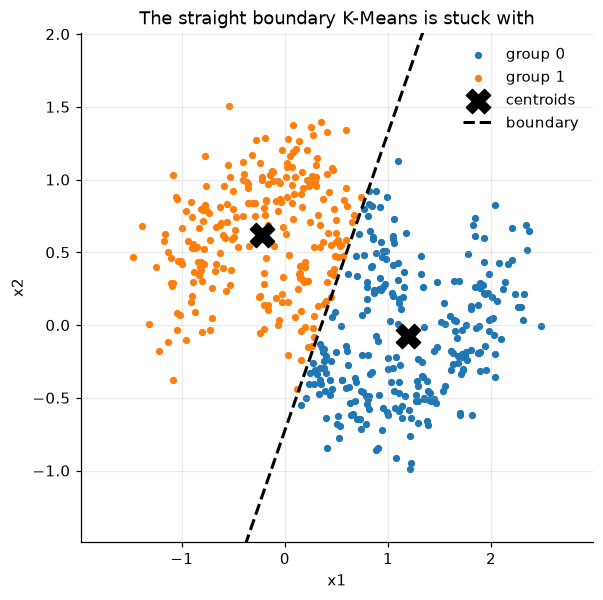

centre A [1.198, -0.077] | centre B [-0.225, 0.618]
midpoint [0.487, 0.271]


In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Take the two rows of kmeans.cluster_centers_ as `a` and `b`.
# 2) The midpoint is (a + b) / 2. The direction from a to b is b - a.
# 3) A direction at right angles to (dx, dy) is (-dy, dx). Walk along it from the midpoint
#    with midpoint + t[:, None] * normal, where t = np.linspace(-2, 2, 100).
# 4) Plot the clusters first, then the line on the same axes, then fix the limits with
#    ax.set_xlim / ax.set_ylim so the line does not stretch the picture.
# Search: "perpendicular bisector two points numpy"
#
# ١) خذ صفّي kmeans.cluster_centers_ باسمي `a` و`b`.
# ٢) نقطة المنتصف هي (a + b) / 2. والاتّجاه من a إلى b هو b - a.
# ٣) والاتّجاه العمودي على (dx, dy) هو (-dy, dx). امشِ عليه من نقطة المنتصف بـ
#    midpoint + t[:, None] * normal حيث t = np.linspace(-2, 2, 100).
# ٤) ارسم العناقيد أولًا ثم الخطّ على المحاور نفسها، ثم ثبّت الحدود بـ
#    ax.set_xlim / ax.set_ylim لئلّا يمطّ الخطّ الصورة.
# ابحث عن: "perpendicular bisector two points numpy"
# ────────────────────────────────────────────────────────────────────

# 1) المركزان
a, b = kmeans.cluster_centers_

# 2) نقطة المنتصف والاتجاه بينهما
midpoint = (a + b) / 2
dx, dy = b - a

# 3) اتجاه عمودي على الخط الواصل بين المركزين
normal = np.array([-dy, dx])
t = np.linspace(-2, 2, 100)
line = midpoint + t[:, None] * normal

# 4) الرسم
fig, ax = plt.subplots(figsize=(6, 6))
plot_clusters(ax, X, kmeans.labels_, "The straight boundary K-Means is stuck with", centres=kmeans.cluster_centers_)
ax.plot(line[:, 0], line[:, 1], "k--", linewidth=2, label="boundary")
ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.legend()
plt.show()

# TODO: Draw the straight boundary K-Means is using — the perpendicular bisector between its two centroids — on top of the clustered points.
# مهمة: ارسم الحدّ المستقيم الذي تستخدمه K-Means — العمود المنصّف بين مركزيها — فوق النقاط المجمّعة.
print(f"centre A {np.round(a, 3).tolist()} | centre B {np.round(b, 3).tolist()}")
print(f"midpoint {np.round(midpoint, 3).tolist()}")

There it is: one straight line, and it was never going to be anything else. With `k` centroids you get
a floor tiled into `k` straight-edged regions, and a moon is not a straight-edged region.

Compare this with Thursday. The support vector machine drew a curve through almost the same picture —
but it was **told the answer** and could choose a kernel to fit it. K-Means was told nothing, and a
method with no labels has to assume a shape in advance. The shape it assumes is a round blob.

<div dir="rtl" align="right">

ها هو: خطّ مستقيم واحد، وما كان ليكون شيئًا آخر أبدًا. فمع `k` مركزًا تحصل على أرضية مبلّطة إلى `k`
منطقة مستقيمة الحواف، والهلال ليس منطقة مستقيمة الحواف.

قارن هذا بيوم الخميس. فآلة المتّجهات الداعمة رسمت منحنى عبر الصورة نفسها تقريبًا — لكنها **أُخبِرت
بالجواب** واستطاعت اختيار نواة تناسبه. أما K-Means فلم تُخبَر بشيء، والطريقة التي بلا تسميات مضطرّة
إلى افتراض شكل مسبقًا. والشكل الذي تفترضه كتلة مستديرة.

</div>

### Task 2.3 — give it the shape it wants

`make_blobs` comes with scikit-learn and generates exactly that: round, roughly equal-sized clouds.
Nothing to download.

Generate 500 points in 2 blobs with `random_state=42`, cluster them with the same call you used in
Task 1.1, and score them with `adjusted_rand_score` again. Plot the result beside the moons attempt.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — أعطها الشكل الذي تريده

الدالة `make_blobs` تأتي مع scikit-learn وتولّد ذلك تمامًا: سُحبًا مستديرة متقاربة الحجم. ولا شيء
لتنزيله.

ولّد ٥٠٠ نقطة في كتلتين بـ`random_state=42`، وجمّعها بالاستدعاء نفسه الذي استخدمته في المهمة ١٫١،
وقيّمها بـ`adjusted_rand_score` مجدّدًا. وارسم النتيجة بجوار محاولة الهلالين.

</div>

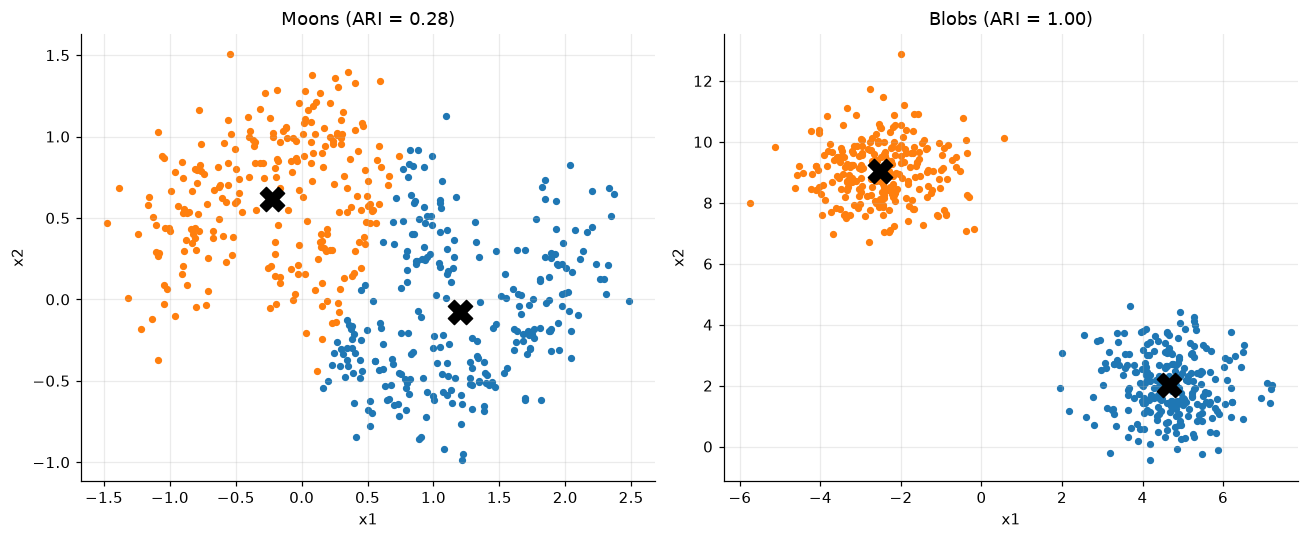

same algorithm on moons : ARI 0.2773
same algorithm on blobs : ARI 1.0000


In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) make_blobs(n_samples=500, centers=2, cluster_std=1.0, random_state=42) returns the
#    points and their true group in one call.
# 2) Cluster with the identical KMeans call from Task 1.1 — same k, same n_init, same seed.
# 3) Score into `ari_blobs`, then plot the blobs beside the moons for the contrast.
# 4) Do not tune anything. If you find yourself tuning, you have missed the point of the task.
# Search: "sklearn make_blobs synthetic clusters"
#
# ١) الدالة make_blobs(n_samples=500, centers=2, cluster_std=1.0, random_state=42) تُرجع
#    النقاط ومجموعتها الحقيقية في استدعاء واحد.
# ٢) جمّع بالاستدعاء نفسه من المهمة ١٫١ — الـk نفسه وn_init نفسه والبذرة نفسها.
# ٣) قيّم في `ari_blobs`، ثم ارسم الكتلتين بجوار الهلالين للمقارنة.
# ٤) لا تضبط شيئًا. فإن وجدت نفسك تضبط فقد فاتك مقصد المهمة.
# ابحث عن: "sklearn make_blobs synthetic clusters"
# ────────────────────────────────────────────────────────────────────
from sklearn.datasets import make_blobs

# 1) توليد بيانات جديدة: كتلتين مستديرتين (مو هلالين)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=2, cluster_std=1.0, random_state=42)

# 2) نفس استدعاء K-Means بالضبط من Task 1.1
kmeans_blobs = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_blobs.fit(X_blobs)

# 3) التقييم
ari_blobs = adjusted_rand_score(y_blobs, kmeans_blobs.labels_)

# رسم المقارنة: الهلالين جنب الكتل
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters(axes[0], X, kmeans.labels_, f"Moons (ARI = {ari_moons:.2f})", centres=kmeans.cluster_centers_)
plot_clusters(axes[1], X_blobs, kmeans_blobs.labels_, f"Blobs (ARI = {ari_blobs:.2f})", centres=kmeans_blobs.cluster_centers_)
plt.tight_layout()
plt.show()

# TODO: Generate two round blobs, cluster them with the same KMeans call, score it into `ari_blobs`, and plot it beside the moons result.
# مهمة: ولّد كتلتين مستديرتين، وجمّعهما بالاستدعاء نفسه، وقيّمه في `ari_blobs`، وارسمه بجوار نتيجة الهلالين.
print(f"same algorithm on moons : ARI {ari_moons:.4f}")
print(f"same algorithm on blobs : ARI {ari_blobs:.4f}")

1.0 — every single point in the right group. Identical call, identical `k`, identical seed. The only
thing that changed was the shape of the data.

So the sentence to take away is not "K-Means is weak". It is: **K-Means asks whether your groups are
round, similarly sized blobs, and answers as if they were.** When they are, it is fast, stable and
hard to beat. When they are not, it still returns an answer, with no error and no warning, and the
only way to notice is to look — which on twelve columns you cannot.

<div dir="rtl" align="right">

١٫٠ — كل نقطة في مجموعتها الصحيحة. الاستدعاء نفسه، والـ`k` نفسه، والبذرة نفسها. والشيء الوحيد الذي
تغيّر هو شكل البيانات.

فالجملة التي تخرج بها ليست «K-Means ضعيفة»، بل: **تسأل K-Means هل مجموعاتك كتل مستديرة متقاربة
الحجم، وتُجيب كما لو كانت كذلك.** فإن كانت كذلك فهي سريعة ومستقرّة ويصعب التفوّق عليها. وإن لم تكن،
فإنها تُرجع جوابًا مع ذلك، بلا خطأ وبلا تحذير، والسبيل الوحيد للانتباه هو النظر — وهو ما لا تستطيعه
مع اثني عشر عمودًا.

</div>

## Section 3 — Stretch: the elbow does not know  (≈10 min)

Open-ended, and lower expectation of completeness. Finish it at home if the room moves on.

`inertia_` is the total squared distance from every point to its own centroid — the quantity K-Means
minimises. The main lab plots it against `k` and looks for the bend.

Do that here, on the moons, for `k` = 1 to 8. You already know clustering was the wrong tool for this
data. Ask whether the plot knows.

<div dir="rtl" align="right">

## القسم الثالث — إضافي: الكوع لا يعلم (نحو ١٠ دقائق)

مفتوح، والتوقّع فيه أقلّ من حيث الاكتمال. أكمله في المنزل إن مضت القاعة.

القيمة `inertia_` هي مجموع مربّعات المسافات من كل نقطة إلى مركزها — وهي الكمّية التي تُصغّرها K-Means.
والمعمل الأساسي يرسمها مقابل `k` ويبحث عن الانحناء.

افعل ذلك هنا على الهلالين لـ`k` من ١ إلى ٨. وأنت تعلم أصلًا أن التجميع كان الأداة الخطأ لهذه البيانات.
فاسأل: هل يعلم الرسم ذلك؟

</div>

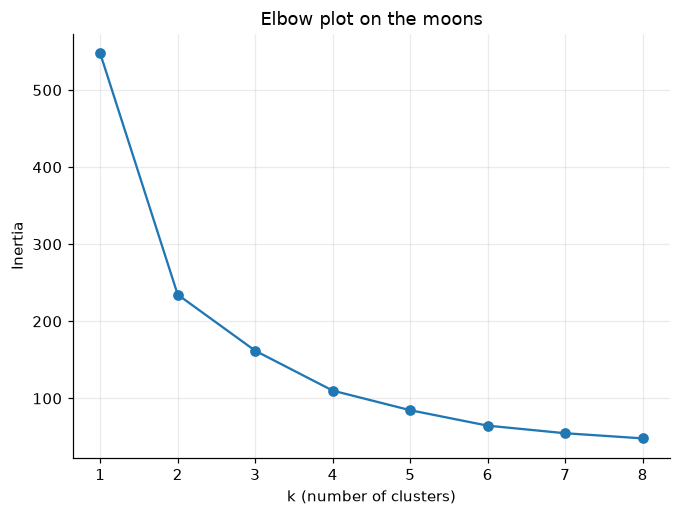

k = 1 | inertia     547.6
k = 2 | inertia     234.7
k = 3 | inertia     161.8
k = 4 | inertia     110.1
k = 5 | inertia      84.7
k = 6 | inertia      64.7
k = 7 | inertia      54.8
k = 8 | inertia      48.1


In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over K_RANGE, fit KMeans(n_clusters=k, n_init=10, random_state=42), keep .inertia_.
# 2) Plot inertia against list(K_RANGE) with markers, and label both axes.
# 3) Name the list `inertias` — the sanity check reads it.
# 4) Then look at the curve and answer the question in the markdown cell below in one line.
# Search: "sklearn KMeans inertia_ elbow method"
#
# ١) كرّر على K_RANGE، ودرّب KMeans(n_clusters=k, n_init=10, random_state=42)، واحفظ ‎.inertia_‎.
# ٢) ارسم القصور الذاتي مقابل list(K_RANGE) بعلامات، وسمِّ المحورين.
# ٣) سمِّ القائمة `inertias` — فالفحص يقرؤها.
# ٤) ثم انظر إلى المنحنى وأجب عن السؤال في خلية النصّ أدناه في سطر واحد.
# ابحث عن: "sklearn KMeans inertia_ elbow method"
# ────────────────────────────────────────────────────────────────────

K_RANGE = range(1, 9)

# 1) احسب inertia لكل قيمة k
inertias = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

# 2) ارسم منحنى الكوع
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(K_RANGE), inertias, marker="o")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow plot on the moons")
plt.show()

# TODO: Record the inertia at every k in K_RANGE into `inertias` and plot the elbow curve.
# مهمة: سجّل القصور الذاتي عند كل k في K_RANGE في `inertias` وارسم منحنى الكوع.
for k, value in zip(K_RANGE, inertias):
    print(f"k = {k} | inertia {value:9.1f}")

**Your answer:** _(one line — does the elbow plot give any sign that K-Means was the wrong tool here?)_

<div dir="rtl" align="right">

**إجابتك:** *(سطر واحد — هل يعطي رسم الكوع أي إشارة إلى أن K-Means كانت الأداة الخطأ هنا؟)*

</div>

## Save your artefact

`kmeans_intro.json` records both scores and the inertia curve. Keep it beside the D4 extras: with
`svm_intro.json` you now have the same 500 points measured once with labels and once without, which is
as clean a statement of the difference between supervised and unsupervised learning as this course
gives you.

<div dir="rtl" align="right">

## احفظ ناتجك

يسجّل الملف `kmeans_intro.json` النتيجتين ومنحنى القصور الذاتي. واحتفظ به بجوار معملَي اليوم الرابع
الإضافيين: فمع `svm_intro.json` صار لديك النقاط الخمسمئة نفسها مقيسةً مرة بالتسميات ومرة بدونها، وهذا
أنظف بيان للفرق بين التعلّم المُوجَّه وغير المُوجَّه تقدّمه لك هذه الدورة.

</div>

In [8]:
metrics = {
    "dataset": "moons_toy",
    "features": FEATURES,
    "n_points": int(len(X)),
    "k": 2,
    "ari_moons": round(ari_moons, 4),
    "ari_blobs": round(ari_blobs, 4),
    "iterations_to_settle": int(kmeans.n_iter_),
    "inertia_by_k": {str(k): round(value, 2) for k, value in zip(K_RANGE, inertias)},
}

out = ARTEFACT_DIR / "kmeans_intro.json"
out.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

Saved c:\Users\ACER\AIEP_Olo_student\week_1_foundations\labs\D5_extra_kmeans\artefacts\kmeans_intro.json
{
  "dataset": "moons_toy",
  "features": [
    "x1",
    "x2"
  ],
  "n_points": 500,
  "k": 2,
  "ari_moons": 0.2773,
  "ari_blobs": 1.0,
  "iterations_to_settle": 9,
  "inertia_by_k": {
    "1": 547.55,
    "2": 234.66,
    "3": 161.85,
    "4": 110.11,
    "5": 84.71,
    "6": 64.65,
    "7": 54.83,
    "8": 48.14
  }
}


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [9]:
# --- Sanity checks ----------------------------------------------------------------
check(ari_moons < 0.60,
      f"K-Means should visibly fail on the moons; yours scores {ari_moons:.4f}, which is too good — "
      f"check you clustered X and compared against y_true, not something else",
      f"يجب أن تفشل K-Means بوضوح على الهلالين، ونتيجتك {ari_moons:.4f} وهي أفضل من اللازم — "
      f"تحقّق أنك جمّعت X وقارنت بـy_true لا بشيء آخر")

check(ari_blobs > 0.90,
      f"the same algorithm must succeed on round blobs: {ari_blobs:.4f} — if it is low, check you "
      f"scored against y_blobs and not y_true",
      f"يجب أن تنجح الخوارزمية نفسها على الكتل المستديرة: {ari_blobs:.4f} — فإن كانت منخفضة فتحقّق "
      f"أنك قارنت بـy_blobs لا بـy_true")

check(ari_blobs - ari_moons > 0.50,
      f"the gap between the two shapes is the lesson, and yours is only "
      f"{ari_blobs - ari_moons:.4f}",
      f"الفجوة بين الشكلين هي الدرس، وفجوتك {ari_blobs - ari_moons:.4f} فقط")

check(len(steps) == len(SNAPSHOTS),
      f"you need one fitted model per value in SNAPSHOTS ({len(SNAPSHOTS)}), got {len(steps)}",
      f"تحتاج نموذجًا مُدرَّبًا لكل قيمة في SNAPSHOTS ({len(SNAPSHOTS)})، ولديك {len(steps)}")

check(steps[0].n_iter_ < steps[-1].n_iter_,
      f"capping max_iter at 1 must stop the loop earlier than letting it run: "
      f"{steps[0].n_iter_} vs {steps[-1].n_iter_} iterations",
      f"تحديد max_iter بـ١ يجب أن يوقف الحلقة قبل تركها تعمل: "
      f"{steps[0].n_iter_} مقابل {steps[-1].n_iter_} تكرارًا")

check(len(inertias) == len(list(K_RANGE)) and all(
        inertias[i] > inertias[i + 1] for i in range(len(inertias) - 1)),
      f"inertia must fall at every step of k — adding a centroid can never make it worse; "
      f"yours: {[round(v, 1) for v in inertias]}",
      f"يجب أن يهبط القصور الذاتي عند كل زيادة في k — فإضافة مركز لا تزيده أبدًا؛ "
      f"وقيمك: {[round(v, 1) for v in inertias]}")

check((ARTEFACT_DIR / "kmeans_intro.json").exists(),
      "kmeans_intro.json should exist — run the save cell above",
      "يجب أن يوجد الملف kmeans_intro.json — شغّل خلية الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  K-Means should visibly fail on the moons; yours scores 0.2773, which is too good — check you clustered X and compared against y_true, not something else
  ✓  the same algorithm must succeed on round blobs: 1.0000 — if it is low, check you scored against y_blobs and not y_true
  ✓  the gap between the two shapes is the lesson, and yours is only 0.7227
  ✓  you need one fitted model per value in SNAPSHOTS (4), got 4
  ✓  capping max_iter at 1 must stop the loop earlier than letting it run: 1 vs 9 iterations
  ✓  inertia must fall at every step of k — adding a centroid can never make it worse; yours: [547.6, 234.7, 161.8, 110.1, 84.7, 64.7, 54.8, 48.1]
  ✓  kmeans_intro.json should exist — run the save cell above
──────────────────────────────────────────────────────────────────
  ✅ All 7 checks passed. / اجتزت جميع الفحوصات (7).
──────────────────────────────────────────────────────────────────


## What's next

K-Means could not see the moons because it can only draw straight lines between centroids. The other
extra lab today, `D5_extra_pca_tsne`, takes the opposite problem — data with sixty-four columns
instead of two — and asks how to get it onto a page at all without lying about it.

<div dir="rtl" align="right">

## ماذا بعد

لم تستطع K-Means رؤية الهلالين لأنها لا ترسم إلا خطوطًا مستقيمة بين المراكز. والمعمل الإضافي الآخر
اليوم، `D5_extra_pca_tsne`، يتناول المسألة المعاكسة — بيانات بأربعة وستّين عمودًا لا عمودين — ويسأل
كيف تضعها على صفحة أصلًا دون أن تكذب عليها.

</div>